In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [24]:
DATA_DIR = "FinalDataset"
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 20
PATIENCE = 5

In [25]:
BATCH_SIZES = [16, 32]
LRS = [1e-3, 1e-4]
DROPOUTS = [0.3, 0.5]

transformator

In [26]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

hyperparameter tune and training loop

In [27]:
results = []

for bs in BATCH_SIZES:
    for lr in LRS:
        for dp in DROPOUTS:

            print(f"\nBS={bs}, LR={lr}, DP={dp}")

            train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_tf)
            val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), val_tf)
            test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), val_tf)

            train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
            val_loader   = DataLoader(val_dataset, batch_size=bs)
            test_loader  = DataLoader(test_dataset, batch_size=bs)

            class_names = train_dataset.classes
            print("Classes:", class_names)

            model = models.mobilenet_v2(weights='DEFAULT')

            for param in model.parameters():
                param.requires_grad = False

            model.classifier[1] = nn.Sequential(
                nn.Dropout(dp),
                nn.Linear(model.last_channel, len(class_names))
            )

            model = model.to(DEVICE)

            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.classifier.parameters(), lr=lr)

            history = {
                "train_loss": [],
                "val_loss": [],
                "train_acc": [],
                "val_acc": []
            }

            best_acc = 0
            best_model = model.state_dict()

            patience_counter = 0
            best_val_loss = 999

            for epoch in range(EPOCHS):

                print(f"\nEpoch {epoch+1}/{EPOCHS}")

                model.train()
                total_loss = 0
                correct = 0

                for inputs, labels in train_loader:
                    inputs = inputs.to(DEVICE)
                    labels = labels.to(DEVICE)

                    optimizer.zero_grad()

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    loss.backward()
                    optimizer.step()

                    _, preds = torch.max(outputs, 1)

                    total_loss += loss.item() * inputs.size(0)
                    correct += torch.sum(preds == labels)

                train_loss = total_loss / len(train_dataset)
                train_acc = correct.double() / len(train_dataset)

                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc.item())

                print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

                model.eval()
                total_loss = 0
                correct = 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs = inputs.to(DEVICE)
                        labels = labels.to(DEVICE)

                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                        _, preds = torch.max(outputs, 1)

                        total_loss += loss.item() * inputs.size(0)
                        correct += torch.sum(preds == labels)

                val_loss = total_loss / len(val_dataset)
                val_acc = correct.double() / len(val_dataset)

                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc.item())

                print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
                print(f"Gap: {(train_acc - val_acc):.4f}")

                if val_acc > best_acc:
                    best_acc = val_acc
                    best_model = model.state_dict()

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= PATIENCE:
                        print("Early stopping")
                        break

            results.append({
                "bs": bs,
                "lr": lr,
                "dp": dp,
                "acc": best_acc,
                "model": best_model,
                "history": history
            })


BS=16, LR=0.001, DP=0.3
Classes: ['apple', 'banana', 'orange']

Epoch 1/20
Train Loss: 0.5816 | Acc: 0.8093
Val Loss: 0.1669 | Acc: 0.9968
Gap: -0.1876

Epoch 2/20
Train Loss: 0.3381 | Acc: 0.8971
Val Loss: 0.1004 | Acc: 0.9968
Gap: -0.0997

Epoch 3/20
Train Loss: 0.2700 | Acc: 0.9137
Val Loss: 0.0720 | Acc: 0.9968
Gap: -0.0831

Epoch 4/20
Train Loss: 0.2652 | Acc: 0.9074
Val Loss: 0.0632 | Acc: 0.9968
Gap: -0.0894

Epoch 5/20
Train Loss: 0.2431 | Acc: 0.9110
Val Loss: 0.0543 | Acc: 0.9968
Gap: -0.0859

Epoch 6/20
Train Loss: 0.2135 | Acc: 0.9272
Val Loss: 0.0488 | Acc: 0.9968
Gap: -0.0696

Epoch 7/20
Train Loss: 0.2307 | Acc: 0.9185
Val Loss: 0.0464 | Acc: 0.9936
Gap: -0.0752

Epoch 8/20
Train Loss: 0.1915 | Acc: 0.9319
Val Loss: 0.0440 | Acc: 0.9968
Gap: -0.0649

Epoch 9/20
Train Loss: 0.2309 | Acc: 0.9169
Val Loss: 0.0444 | Acc: 0.9968
Gap: -0.0799

Epoch 10/20
Train Loss: 0.2151 | Acc: 0.9153
Val Loss: 0.0410 | Acc: 0.9968
Gap: -0.0815

Epoch 11/20
Train Loss: 0.2201 | Acc: 0.9272


Best Setup: 16 0.001 0.3


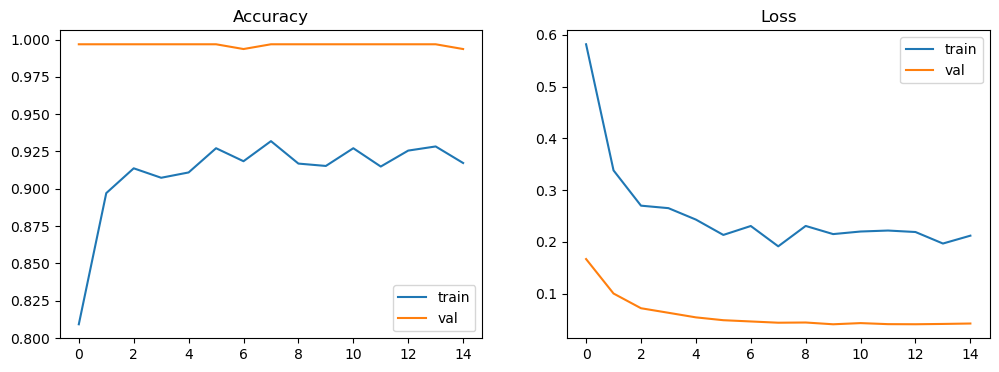

In [28]:
best = max(results, key=lambda x: x["acc"])
hist = best["history"]

print("\nBest Setup:", best["bs"], best["lr"], best["dp"])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist["train_acc"], label="train")
plt.plot(hist["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["train_loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.show()

Rebuild Model Cleanly (No Leaks)

In [29]:
bs = best["bs"]

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), val_tf)
test_loader = DataLoader(test_dataset, batch_size=bs)

class_names = test_dataset.classes

model = models.mobilenet_v2(weights='DEFAULT')

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Sequential(
    nn.Dropout(best["dp"]),
    nn.Linear(model.last_channel, len(class_names))
)

model = model.to(DEVICE)
model.load_state_dict(best["model"])
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [30]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

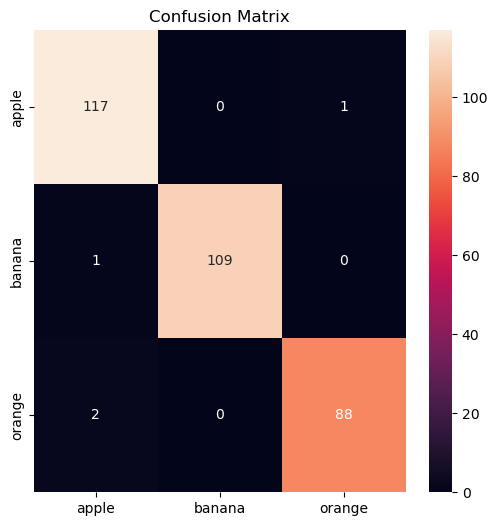


Classification Report:

              precision    recall  f1-score   support

       apple       0.97      0.99      0.98       118
      banana       1.00      0.99      1.00       110
      orange       0.99      0.98      0.98        90

    accuracy                           0.99       318
   macro avg       0.99      0.99      0.99       318
weighted avg       0.99      0.99      0.99       318



In [31]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [32]:
torch.save(model.state_dict(), "best_model.pth")